In [29]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
import torch
import random

import os
import sys
sys.path.append(os.path.abspath(os.path.join('../..')))

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from reservoirgrid.models import Reservoir
from reservoirgrid.helpers import chaos_utils
from reservoirgrid.helpers import utils
from reservoirgrid.helpers import viz

In [30]:
def set_seed(seed=42):
    """
    Sets the seed for all random number generators to ensure reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Ensure deterministic algorithms (might slow down slightly but ensures precision)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Seed set to: {seed}")

# --- 2. Set the seed BEFORE creating data or models ---
set_seed(42)


Seed set to: 42


In [31]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('GPU is available')
else:
    device = torch.device('cpu')
    print('CPU is available')

GPU is available


In [32]:
path = "../../Examples/Weight_Landscape/results/Chaotic/"
save_path = "../../Examples/Weight_Landscape/Plots/SingleMetric/"
system_name = "Lorenz"
system_path = os.path.join(path, system_name)

file = os.path.join(system_path, "75.0.pkl")
with open(file, "rb") as f:
    data_10 = pickle.load(f)

In [49]:
data

{'parameters': {'SpectralRadius': np.float64(0.71),
  'LeakyRate': np.float64(0.71),
  'InputScaling': np.float64(0.59)},
 'metrics': {'RMSE': 0.44467339626132224},
 'predictions': tensor([[-0.3603, -0.4177,  0.2677],
         [-0.3715, -0.4327,  0.2460],
         [-0.3837, -0.4503,  0.2270],
         ...,
         [ 0.0639, -0.0599, -0.4668],
         [ 0.0392, -0.0822, -0.4648],
         [ 0.0147, -0.1072, -0.4719]], dtype=torch.float64),
 'readout_weights': array([[-0.00988369,  0.00038254,  0.00176131, ...,  0.001655  ,
         -0.00046181, -0.00208054],
        [-0.0191203 , -0.0057595 ,  0.00096271, ...,  0.00163705,
          0.00333668, -0.00626657],
        [-0.01872027,  0.00899364, -0.01256561, ..., -0.02416198,
         -0.00498744,  0.00265484]], shape=(3, 1300)),
 'true_value': array([[-0.36095741, -0.41188175,  0.26993806],
        [-0.37120656, -0.42313015,  0.24946626],
        [-0.38189641, -0.43716652,  0.23192462],
        ...,
        [ 0.02770161,  0.01140504,  0

In [51]:
all_lyapunov = []
all_kldiv = []
all_params = []
all_jsdiv = []
all_skl = []
all_rmse = []

for data in data_10:
    lyap1 = chaos_utils.lyapunov_time(data["true_value"], data["predictions"])
    Kldiv = chaos_utils.kl_divergence(data["true_value"], data["predictions"])
    jsdiv = chaos_utils.js_divergence(data["true_value"], data["predictions"])
    skl = chaos_utils.symmetric_kl(data["true_value"], data["predictions"])
    rmse = data["metrics"]["RMSE"]

    all_skl.append(skl)
    all_jsdiv.append(jsdiv)
    all_lyapunov.append(lyap1)
    all_kldiv.append(Kldiv)
    all_rmse.append(rmse)
    
    params = data["parameters"]
    all_params.append(params)

In [57]:
jsidx = np.argpartition(all_jsdiv, 5)[:5]
klidx = np.argpartition(all_kldiv, 5)[:5]
sklidx = np.argpartition(all_skl, 5)[:5]
rmseidx = np.argpartition(all_rmse, 5)[:5]

In [35]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# define grid shape


In [58]:
n = len(jsidx)
cols = 5   # needs atleast 10 values to se how the kl divergence favours the coverage of base attractor over the perfect coverage
rows = int(np.ceil(n / cols))

clean_scene = dict(
    camera=dict(
        eye=dict(x=-1.5, y=1.5, z=0.5),
        center=dict(x=0, y=0, z=0),
        up=dict(x=0, y=0, z=1)
    ),
    xaxis=dict(showbackground=False, showgrid=False, zeroline=False,
               showticklabels=False, title=''),
    yaxis=dict(showbackground=False, showgrid=False, zeroline=False,
               showticklabels=False, title=''),
    zaxis=dict(showbackground=False, showgrid=False, zeroline=False,
               showticklabels=False, title=''),
    # optional: aspect ratio
    aspectmode="data"    
)

# create subplot figure with 3D subplots
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{"type": "scene"} for _ in range(cols)] for _ in range(rows)],
    #subplot_titles=[f"{all_skl[u]:.4f}" for u in sklidx],
    horizontal_spacing = 0 ,  # reduce horizontal gap (0 = no gap)
    vertical_spacing = 0     # reduce vertical gap
)

# loop and add traces
for i, u in enumerate(rmseidx):
    r, c = divmod(i, cols)

    # call your existing function
    best_js = np.array([
        data_10[u]["true_value"],
        data_10[u]["predictions"].numpy()
    ])
    subfig = viz.compare_plot(best_js)  # <- returns a plotly figure

    # extract traces and add them into subplot
    for trace in subfig.data:
        fig.add_trace(trace, row=r+1, col=c+1)
        
# Apply to all subplot scenes
layout_updates = {}
for i in range(1, rows*cols + 1):
    scene_name = "scene" if i == 1 else f"scene{i}"
    layout_updates[scene_name] = clean_scene

fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0),  # trim margins
    showlegend = False,
    **layout_updates
)

fig.write_image("rmse_best.png", width=1250, height=300,scale=3)
fig.show()

Processing 500 results...


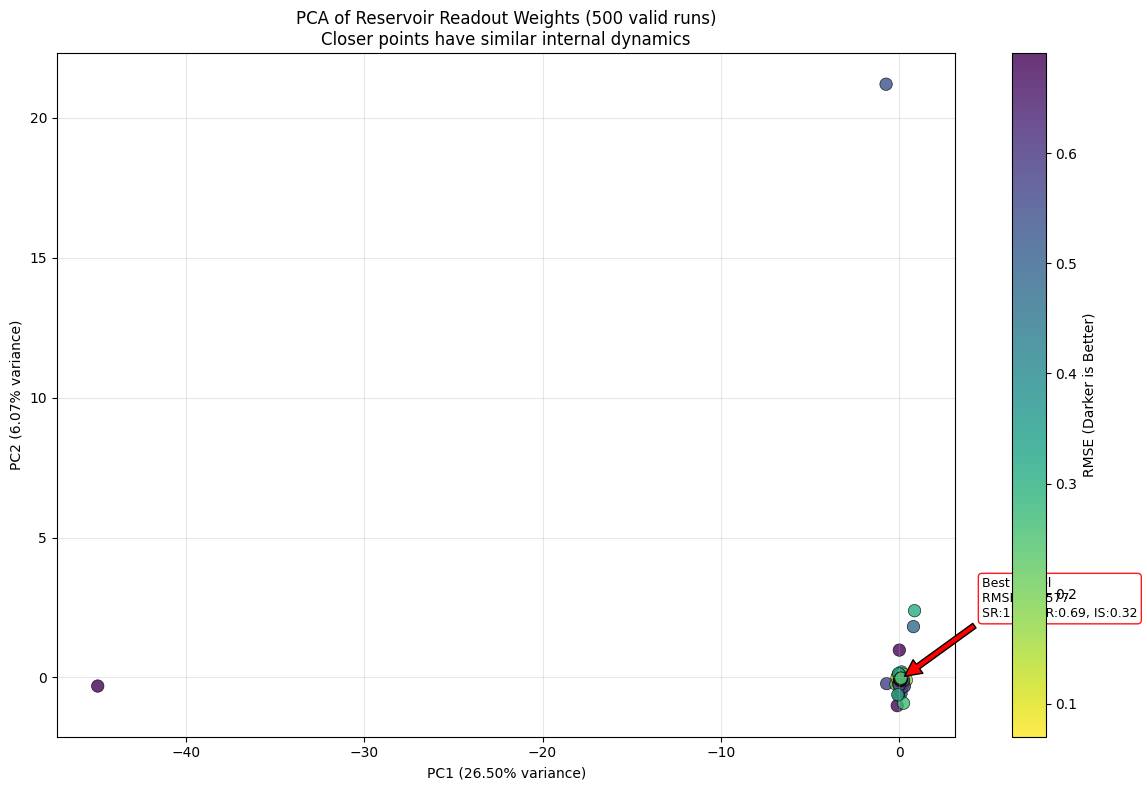

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_weight_space_pca(results_list):
    """
    Performs PCA on the readout weights to visualize the solution space.
    
    Args:
        results_list: The list returned by parameter_sweep()
                      Each item must have 'readout_weights', 'metrics', and 'parameters'.
    """
    
    # 1. Prepare Data Containers
    weight_vectors = []
    mses = []
    jsdivs = []
    param_info = [] # Store text info for the best model

    print(f"Processing {len(results_list)} results...")

    for i, res in enumerate(results_list):
        # Extract weights
        # Shape is usually (Output_Dim, Reservoir_Size)
        w_matrix = res['readout_weights'] 
        
        # Extract Metric (RMSE)
        # Handle cases where RMSE might be inside a dict or just a float
        try:
            mse_val = res['metrics']['RMSE']
            jsdiv = chaos_utils.js_divergence(res["true_value"], res["predictions"])
        except KeyError:
            print(f"Skipping index {i}: RMSE not found")
            continue

        # --- CRITICAL SAFETY CHECK ---
        # Reservoir weights often explode to Infinity or NaN with bad parameters.
        # PCA will crash if we don't filter these out.
        if np.isnan(w_matrix).any() or np.isinf(w_matrix).any() or np.isnan(mse_val) or np.isinf(mse_val):
            # print(f"Skipping index {i}: unstable solution (NaN/Inf).")
            continue

        # Flatten the matrix into a 1D vector so PCA can eat it
        # e.g., shape (3, 100) -> (300,)
        w_flat = w_matrix.flatten()
        
        weight_vectors.append(w_flat)
        mses.append(mse_val)
        jsdivs.append(jsdiv)
        
        # Store parameter string for labeling
        p = res['parameters']
        p_str = f"SR:{p['SpectralRadius']:.2f}, LR:{p['LeakyRate']:.2f}, IS:{p['InputScaling']:.2f}"
        param_info.append(p_str)

    # Convert to NumPy array
    X = np.array(weight_vectors)
    mses = np.array(mses)
    jsdivs = np.array(jsdivs)

    if len(X) < 2:
        print("Not enough valid models to perform PCA.")
        return

    # 2. Run PCA
    # We reduce the high-dimensional weight space to 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)

    # 3. Plotting
    plt.figure(figsize=(12, 8))
    
    # Scatter plot
    # cmap='viridis_r' reverses colors so Dark Purple = Low Error (Good), Yellow = High Error (Bad)
    sc = plt.scatter(coords[:, 0], coords[:, 1], c=jsdivs, cmap='viridis_r', s=80, alpha=0.8, edgecolors='k', linewidth=0.5)
    
    # Colorbar
    cbar = plt.colorbar(sc)
    cbar.set_label('RMSE (Darker is Better)')

    # Titles and Labels
    plt.title(f"PCA of Reservoir Readout Weights ({len(X)} valid runs)\nCloser points have similar internal dynamics")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.grid(True, alpha=0.3)

    # 4. Annotate the Best Model
    best_idx = np.argmin(mses)
    best_x, best_y = coords[best_idx]
    best_score = mses[best_idx]
    best_params = param_info[best_idx]

    # Draw an arrow to the best point
    plt.annotate(
        f"Best Model\nRMSE: {best_score:.4f}\n{best_params}", 
        xy=(best_x, best_y), 
        xytext=(best_x + (np.max(coords[:,0]) - np.min(coords[:,0]))*0.1, 
                best_y + (np.max(coords[:,1]) - np.min(coords[:,1]))*0.1),
        arrowprops=dict(facecolor='red', shrink=0.05),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.9),
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Assuming 'results' is the list returned from your parameter_sweep function
plot_weight_space_pca(data_10)